In [1]:
%matplotlib inline
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = Path("COMP9517_26T3_Lab1_Images")

def load_gray(filename, image_dir):
    path = Path(image_dir) / filename
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return image.astype(np.float64)

Task 1

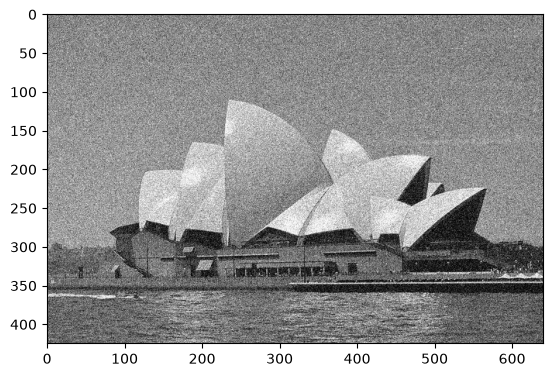

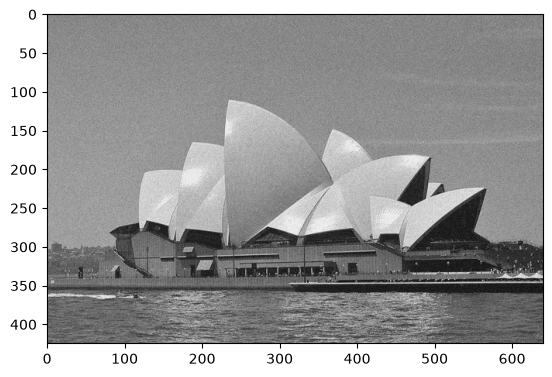

sd in Opera01: 25.3978
sd in average: 8.3254
ratio: 3.0507
should be: 3.1623


In [2]:
opera = np.stack([load_gray(f"Opera{i:02d}.jpg", IMAGE_DIR)
                  for i in range(1, 11)], axis=0)
average = np.mean(opera, axis=0)

# Top-left sky ROI for noise measurement.
x0, x1, y0, y1 = 20, 120, 20, 100
std_single = np.std(opera[0, y0:y1, x0:x1])
std_average = np.std(average[y0:y1, x0:x1])
ratio = std_single / std_average

plt.imshow(opera[0], cmap="gray", vmin=0, vmax=255)
plt.show()

plt.imshow(average, cmap="gray", vmin=0, vmax=255)
plt.show()

print(f"sd in Opera01: {std_single:.4f}")
print(f"sd in average: {std_average:.4f}")
print(f"ratio: {ratio:.4f}")
print(f"should be: {np.sqrt(10):.4f}")

It should be sqrt(10) which is 3.1623

It is actually 3.0507, a bit lower, may caused by residual structure or image issue

Task 2

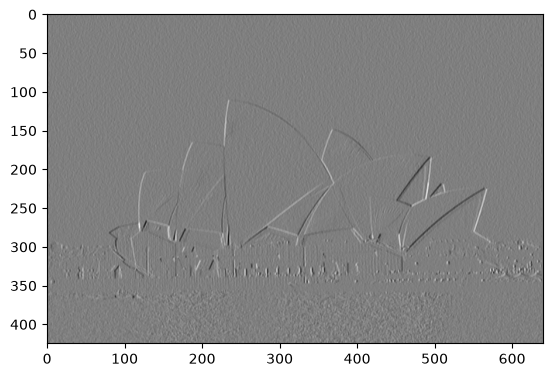

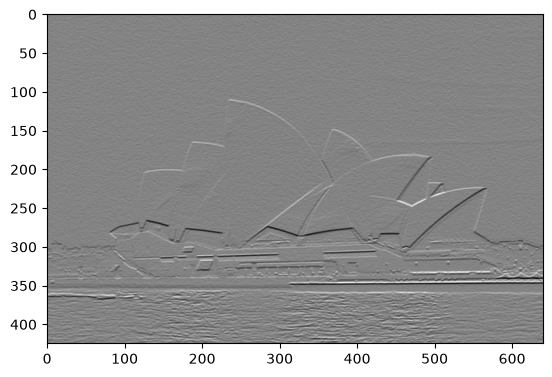

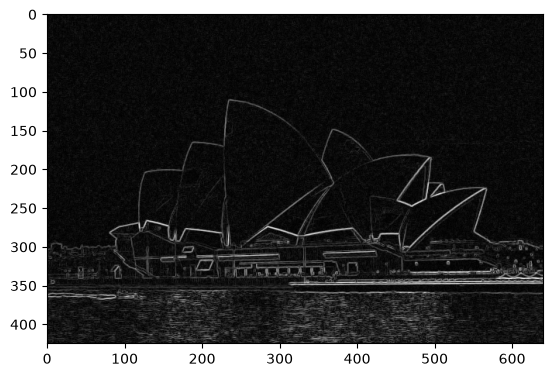

In [3]:
PX = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float64)
PY = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float64)

def prewitt_gradient(image):
    image = np.asarray(image, dtype=np.float64)
    dx = cv2.filter2D(image, cv2.CV_64F, cv2.flip(PX, -1),
                      borderType=cv2.BORDER_REFLECT_101)
    dy = cv2.filter2D(image, cv2.CV_64F, cv2.flip(PY, -1),
                      borderType=cv2.BORDER_REFLECT_101)
    magnitude = np.hypot(dx, dy)
    return dx, dy, magnitude

dx, dy, magnitude = prewitt_gradient(average)

plt.imshow(dx, cmap="gray")
plt.show()

plt.imshow(dy, cmap="gray")
plt.show()

plt.imshow(magnitude, cmap="gray")
plt.show()

Prewitt kernel

Task 3

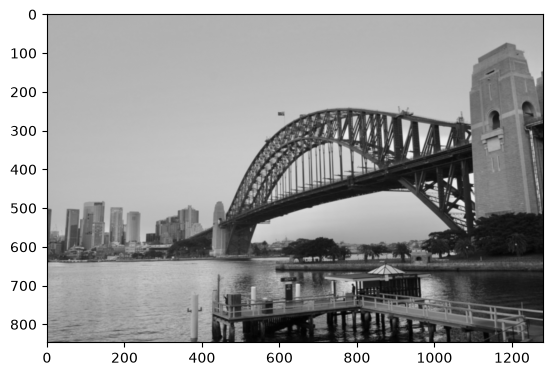

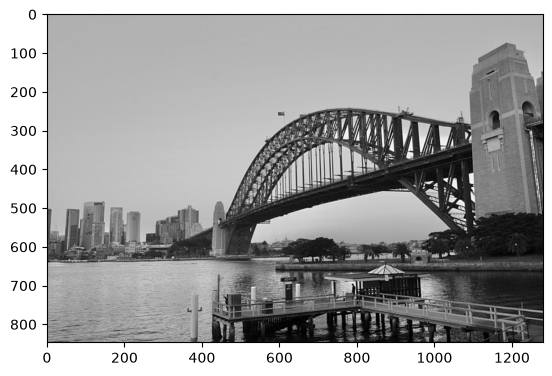

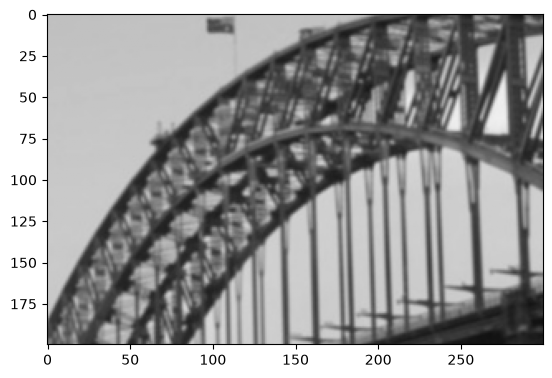

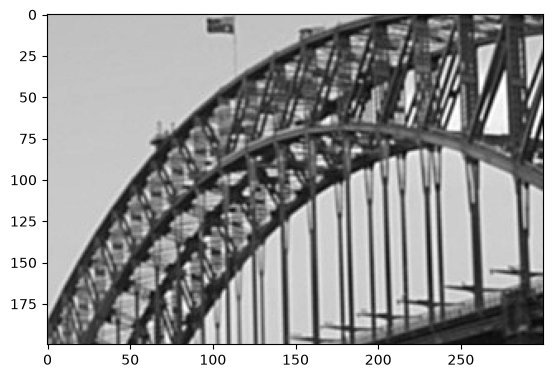

In [4]:
SIGMA = 1.0
AMOUNT = 2.0

def unsharp_mask(image, sigma, amount):
    image = np.asarray(image, dtype=np.float64)
    blurred = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma,
                               borderType=cv2.BORDER_REFLECT_101)
    return np.clip(image + amount * (image - blurred), 0, 255)

bridge = load_gray("Bridge.jpg", IMAGE_DIR)
sharpened = unsharp_mask(bridge, SIGMA, AMOUNT)

plt.imshow(bridge, cmap="gray", vmin=0, vmax=255)
plt.show()

plt.imshow(sharpened, cmap="gray", vmin=0, vmax=255)
plt.show()

detail = np.s_[250:450, 500:800]
plt.imshow(bridge[detail], cmap="gray", vmin=0, vmax=255)
plt.show()

plt.imshow(sharpened[detail], cmap="gray", vmin=0, vmax=255)
plt.show()